In [ ]:
import pandas as pd

# Load the dataset
df = pd.read_csv('/content/Sahan Dataset Telco_Customer_Churn.csv')

# Display the first few rows of the DataFrame
print(df.head())

   customerID  gender  SeniorCitizen Partner Dependents  tenure PhoneService  \
0  7590-VHVEG  Female              0     Yes         No       1           No   
1  5575-GNVDE    Male              0      No         No      34          Yes   
2  3668-QPYBK    Male              0      No         No       2          Yes   
3  7795-CFOCW    Male              0      No         No      45           No   
4  9237-HQITU  Female              0      No         No       2          Yes   

      MultipleLines InternetService OnlineSecurity  ... DeviceProtection  \
0  No phone service             DSL             No  ...               No   
1                No             DSL            Yes  ...              Yes   
2                No             DSL            Yes  ...               No   
3  No phone service             DSL            Yes  ...              Yes   
4                No     Fiber optic             No  ...               No   

  TechSupport StreamingTV StreamingMovies        Contract Pape

In [ ]:
# Install ydata-profiling (successor to pandas-profiling)
!pip install ydata-profiling

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 400.4/400.4 kB 9.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 296.7/296.7 kB 21.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 60.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 679.7/679.7 kB 42.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 105.4/105.4 kB 8.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 68.0/68.0 kB 5.8 MB/s eta 0:00:00


In [ ]:
from ydata_profiling import ProfileReport

# Generate the profiling report
profile = ProfileReport(df, title="Telco Customer Churn Dataset Profile")

# Display the report in the notebook
profile.to_notebook_iframe()

Summarize dataset:   0%|          | 0/5 [00:00<?, ?it/s]


100%|██████████| 21/21 [00:00<00:00, 21.93it/s]


Generate report structure:   0%|          | 0/1 [00:00<?, ?it/s]

Render HTML:   0%|          | 0/1 [00:00<?, ?it/s]

### Exploratory Data Analysis

In [ ]:
# Display basic information about the DataFrame
print('DataFrame Info:')
df.info()

DataFrame Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non

In [ ]:
# Display descriptive statistics for numerical columns
print('\nDescriptive Statistics for Numerical Columns:')
display(df.describe())


Descriptive Statistics for Numerical Columns:


,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


In [ ]:
# Convert 'TotalCharges' to numeric, coercing errors to NaN
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

# Fill NaN values in 'TotalCharges' with 0 (assuming NaN means no charges for new customers)
df['TotalCharges'] = df['TotalCharges'].fillna(0)

# Verify the conversion
print('\nDataFrame Info after TotalCharges conversion:')
df.info()

# Display descriptive statistics for numerical columns again to include TotalCharges
print('\nDescriptive Statistics for Numerical Columns after TotalCharges conversion:')
display(df.describe())


DataFrame Info after TotalCharges conversion:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 


,SeniorCitizen,tenure,MonthlyCharges,TotalCharges
count,7043.000000,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692,2279.734304
std,0.368612,24.559481,30.090047,2266.794470
min,0.000000,0.000000,18.250000,0.000000
25%,0.000000,9.000000,35.500000,398.550000
50%,0.000000,29.000000,70.350000,1394.550000
75%,0.000000,55.000000,89.850000,3786.600000
max,1.000000,72.000000,118.750000,8684.800000


/tmp/ipykernel_6669/1211496446.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Churn', data=df, palette='viridis')


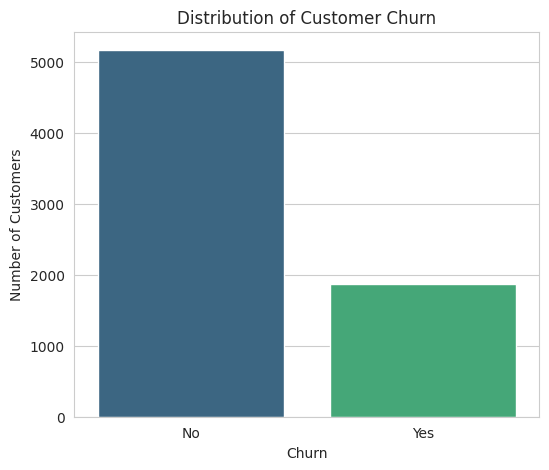

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set a style for the plots
sns.set_style('whitegrid')

# Bar Chart for Churn distribution
plt.figure(figsize=(6, 5))
sns.countplot(x='Churn', data=df, palette='viridis')
plt.title('Distribution of Customer Churn')
plt.xlabel('Churn')
plt.ylabel('Number of Customers')
plt.show()

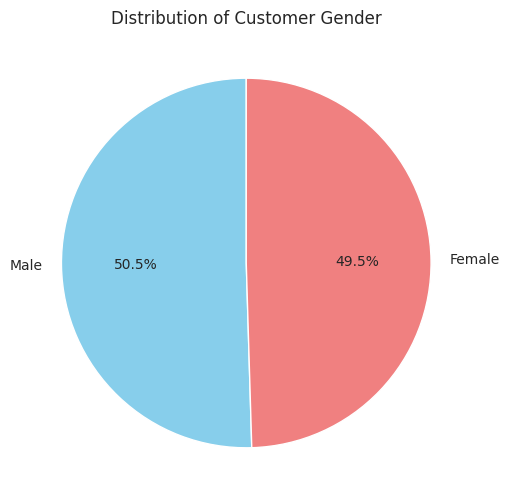

In [ ]:
# Pie Chart for Gender distribution
plt.figure(figsize=(6, 6))
df['gender'].value_counts().plot.pie(autopct='%1.1f%%', startangle=90, colors=['skyblue', 'lightcoral'])
plt.title('Distribution of Customer Gender')
plt.ylabel('') # Hide the default 'gender' label on the y-axis
plt.show()

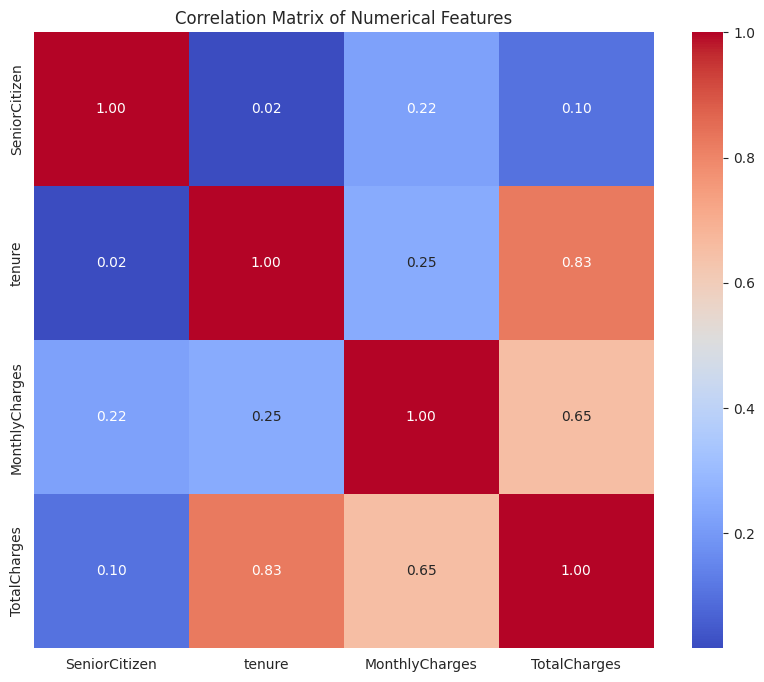

In [ ]:
# Correlation Matrix for numerical columns
# Select only numerical columns for correlation
numerical_cols = df.select_dtypes(include=['int64', 'float64']).columns
correlation_matrix = df[numerical_cols].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Matrix of Numerical Features')
plt.show()

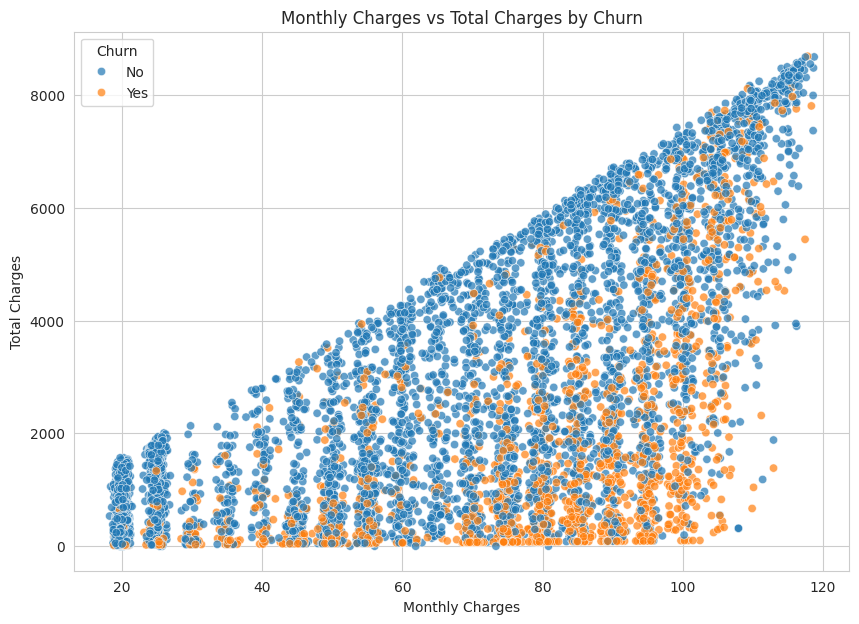

In [ ]:
# Scatter Plot of MonthlyCharges vs TotalCharges, colored by Churn
plt.figure(figsize=(10, 7))
sns.scatterplot(x='MonthlyCharges', y='TotalCharges', hue='Churn', data=df, alpha=0.7)
plt.title('Monthly Charges vs Total Charges by Churn')
plt.xlabel('Monthly Charges')
plt.ylabel('Total Charges')
plt.show()

### Outlier Detection using Box Plots

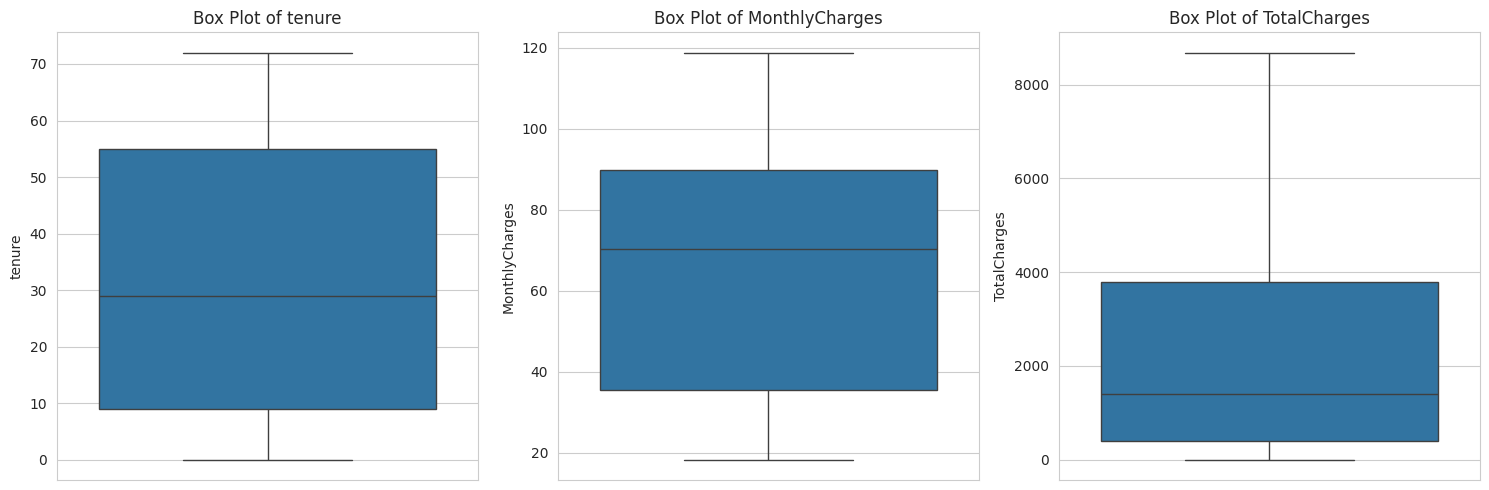

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

numerical_cols_for_outliers = ['tenure', 'MonthlyCharges', 'TotalCharges']

plt.figure(figsize=(15, 5))
for i, col in enumerate(numerical_cols_for_outliers):
    plt.subplot(1, len(numerical_cols_for_outliers), i + 1)
    sns.boxplot(y=df[col])
    plt.title(f'Box Plot of {col}')
    plt.ylabel(col)
plt.tight_layout()
plt.show()

### Checking for Null Values

In [ ]:
print('Null values per column:')
display(df.isnull().sum())

Null values per column:


,0
customerID,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0


In [ ]:
from sklearn.preprocessing import LabelEncoder

# Define target variable 'y'
y = df['Churn'].copy()

# Define features 'X' (all columns except 'customerID' and 'Churn')
X = df.drop(columns=['customerID', 'Churn']).copy()

# Encode the target variable 'y'
# 'Yes' will be 1, 'No' will be 0
le = LabelEncoder()
y = le.fit_transform(y)

print("Encoded Churn values:")
print(y[:5]) # Display first 5 encoded values
print("\nOriginal Churn classes:")
print(le.classes_) # Display original classes

Encoded Churn values:
[0 0 1 0 1]

Original Churn classes:
['No' 'Yes']


In [ ]:
# Display the first few rows of X to verify
print("\nFirst 5 rows of X (features):")
display(X.head())


First 5 rows of X (features):


,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65


In [ ]:
X = pd.get_dummies(X, drop_first=True)

print("First 5 rows of X after One-Hot Encoding:")
display(X.head())

First 5 rows of X after One-Hot Encoding:


,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,gender_Male,Partner_Yes,Dependents_Yes,PhoneService_Yes,MultipleLines_No phone service,MultipleLines_Yes,...,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaperlessBilling_Yes,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,0,1,29.85,29.85,False,True,False,False,True,False,...,False,False,False,False,False,False,True,False,True,False
1,0,34,56.95,1889.50,True,False,False,True,False,False,...,False,False,False,False,True,False,False,False,False,True
2,0,2,53.85,108.15,True,False,False,True,False,False,...,False,False,False,False,False,False,True,False,False,True
3,0,45,42.30,1840.75,True,False,False,False,True,False,...,False,False,False,False,True,False,False,False,False,False
4,0,2,70.70,151.65,False,False,False,True,False,False,...,False,False,False,False,False,False,True,False,True,False


### Preprocessing and Model Training with Pipeline

We'll use `ColumnTransformer` to apply `StandardScaler` to the numerical features and `LogisticRegression` for modeling, all integrated within a `Pipeline` to ensure proper data handling and prevent data leakage.

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Identify numerical features for scaling
# These are the original continuous numerical columns from the dataset
numerical_features = ['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges']

# Create a ColumnTransformer for preprocessing
# StandardScaler will be applied to numerical features
# 'remainder="passthrough"' will keep all other columns (the dummy variables) as they are
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_features)
    ],
    remainder='passthrough'
)

# Create a Pipeline with the preprocessor and a Logistic Regression model
model_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(random_state=42, solver='liblinear')) # Using 'liblinear' solver for better convergence on small datasets
])

# Train the model
model_pipeline.fit(X_train, y_train)

print("Model training complete using Pipeline and ColumnTransformer.")

Model training complete using Pipeline and ColumnTransformer.


### Model Evaluation

In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report

# Make predictions on the test set
y_pred = model_pipeline.predict(X_test)

# Evaluate the model
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
conf_matrix = confusion_matrix(y_test, y_pred)

print(f"\nModel Accuracy: {accuracy:.4f}")
print(f"Model Precision: {precision:.4f}")
print(f"Model Recall: {recall:.4f}")
print(f"Model F1-Score: {f1:.4f}")

print("\nConfusion Matrix:")
print(conf_matrix)

print("\nClassification Report:")
print(classification_report(y_test, y_pred))


Model Accuracy: 0.8048
Model Precision: 0.6562
Model Recall: 0.5561
Model F1-Score: 0.6020

Confusion Matrix:
[[926 109]
 [166 208]]

Classification Report:
              precision    recall  f1-score   support

           0       0.85      0.89      0.87      1035
           1       0.66      0.56      0.60       374

    accuracy                           0.80      1409
   macro avg       0.75      0.73      0.74      1409
weighted avg       0.80      0.80      0.80      1409



### Train a Stronger Model: Random Forest

Let's train a Random Forest Classifier to see if we can improve upon the baseline Logistic Regression model. Random Forests can capture non-linear relationships and are generally more robust.

In [ ]:
from sklearn.ensemble import RandomForestClassifier

# Create a Pipeline with the preprocessor (from previous step) and a Random Forest Classifier
# Note: While Random Forest doesn't strictly 'need' scaling, it's good practice to keep the preprocessor
# in the pipeline for consistency and if we were to change the model later.
model_pipeline_rf = Pipeline(steps=[
    ('preprocessor', preprocessor), # Use the same preprocessor as before
    ('classifier', RandomForestClassifier(random_state=42)) # Random Forest Classifier
])

# Train the Random Forest model
model_pipeline_rf.fit(X_train, y_train)

print("Random Forest model training complete using Pipeline and ColumnTransformer.")

Random Forest model training complete using Pipeline and ColumnTransformer.


### Random Forest Model Evaluation

In [ ]:
# Make predictions on the test set using the Random Forest model
y_pred_rf = model_pipeline_rf.predict(X_test)

# Evaluate the Random Forest model
accuracy_rf = accuracy_score(y_test, y_pred_rf)
precision_rf = precision_score(y_test, y_pred_rf)
recall_rf = recall_score(y_test, y_pred_rf)
f1_rf = f1_score(y_test, y_pred_rf)
conf_matrix_rf = confusion_matrix(y_test, y_pred_rf)

print(f"\nRandom Forest Model Accuracy: {accuracy_rf:.4f}")
print(f"Random Forest Model Precision: {precision_rf:.4f}")
print(f"Random Forest Model Recall: {recall_rf:.4f}")
print(f"Random Forest Model F1-Score: {f1_rf:.4f}")

print("\nRandom Forest Confusion Matrix:")
print(conf_matrix_rf)

print("\nRandom Forest Classification Report:")
print(classification_report(y_test, y_pred_rf))


Random Forest Model Accuracy: 0.7850
Random Forest Model Precision: 0.6187
Random Forest Model Recall: 0.4947
Random Forest Model F1-Score: 0.5498

Random Forest Confusion Matrix:
[[921 114]
 [189 185]]

Random Forest Classification Report:
              precision    recall  f1-score   support

           0       0.83      0.89      0.86      1035
           1       0.62      0.49      0.55       374

    accuracy                           0.78      1409
   macro avg       0.72      0.69      0.70      1409
weighted avg       0.77      0.78      0.78      1409



### ROC-AUC Curves Comparison

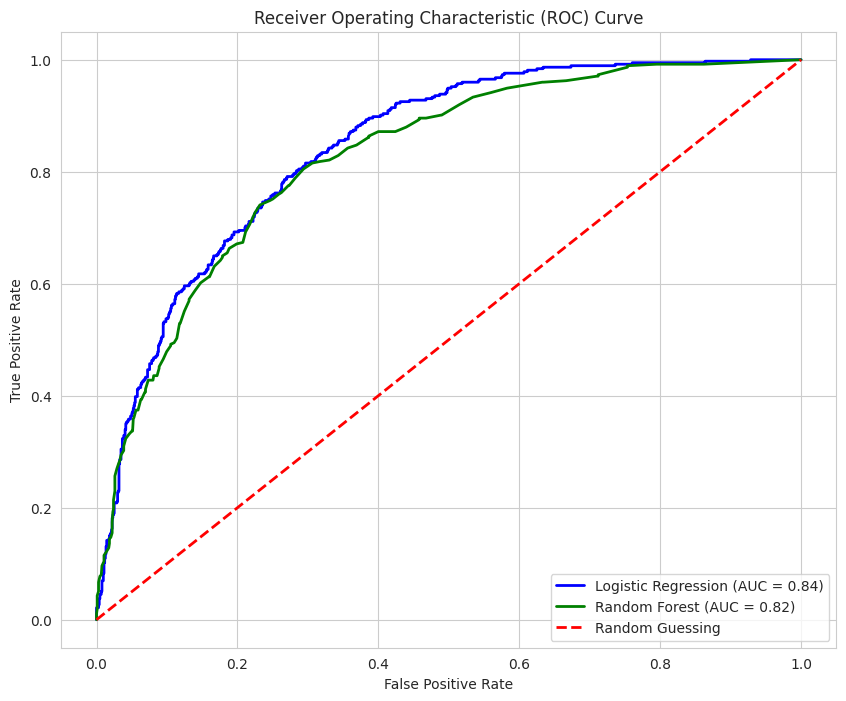

In [ ]:
from sklearn.metrics import roc_curve, auc, RocCurveDisplay
import matplotlib.pyplot as plt

# Get probabilities for the positive class (Churn=Yes)
# Logistic Regression
y_prob_lr = model_pipeline.predict_proba(X_test)[:, 1]

# Random Forest
y_prob_rf = model_pipeline_rf.predict_proba(X_test)[:, 1]

# Calculate ROC curve and AUC for Logistic Regression
fpr_lr, tpr_lr, _ = roc_curve(y_test, y_prob_lr)
roc_auc_lr = auc(fpr_lr, tpr_lr)

# Calculate ROC curve and AUC for Random Forest
fpr_rf, tpr_rf, _ = roc_curve(y_test, y_prob_rf)
roc_auc_rf = auc(fpr_rf, tpr_rf)

# Plot ROC curves
plt.figure(figsize=(10, 8))
plt.plot(fpr_lr, tpr_lr, color='blue', lw=2, label=f'Logistic Regression (AUC = {roc_auc_lr:.2f})')
plt.plot(fpr_rf, tpr_rf, color='green', lw=2, label=f'Random Forest (AUC = {roc_auc_rf:.2f})')
plt.plot([0, 1], [0, 1], color='red', lw=2, linestyle='--', label='Random Guessing')

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()

### Precision-Recall Curves Comparison

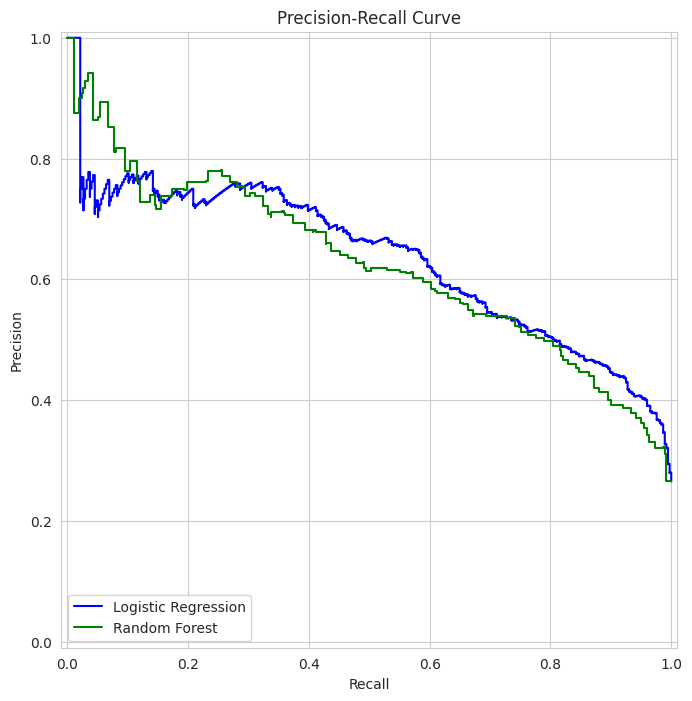

In [ ]:
from sklearn.metrics import precision_recall_curve, PrecisionRecallDisplay
import matplotlib.pyplot as plt

# Get probabilities for the positive class (Churn=Yes)
y_prob_lr = model_pipeline.predict_proba(X_test)[:, 1]
y_prob_rf = model_pipeline_rf.predict_proba(X_test)[:, 1]

# Calculate Precision-Recall curve for Logistic Regression
precision_lr, recall_lr, _ = precision_recall_curve(y_test, y_prob_lr)

# Calculate Precision-Recall curve for Random Forest
precision_rf, recall_rf, _ = precision_recall_curve(y_test, y_prob_rf)

# Plot Precision-Recall curves
plt.figure(figsize=(10, 8))

# Plot for Logistic Regression
display_lr = PrecisionRecallDisplay(precision=precision_lr, recall=recall_lr, estimator_name='Logistic Regression')
display_lr.plot(ax=plt.gca(), color='blue')

# Plot for Random Forest
display_rf = PrecisionRecallDisplay(precision=precision_rf, recall=recall_rf, estimator_name='Random Forest')
display_rf.plot(ax=plt.gca(), color='green')

plt.title('Precision-Recall Curve')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.grid(True)
plt.legend(loc='lower left')
plt.show()

### Feature Importance for Random Forest Model

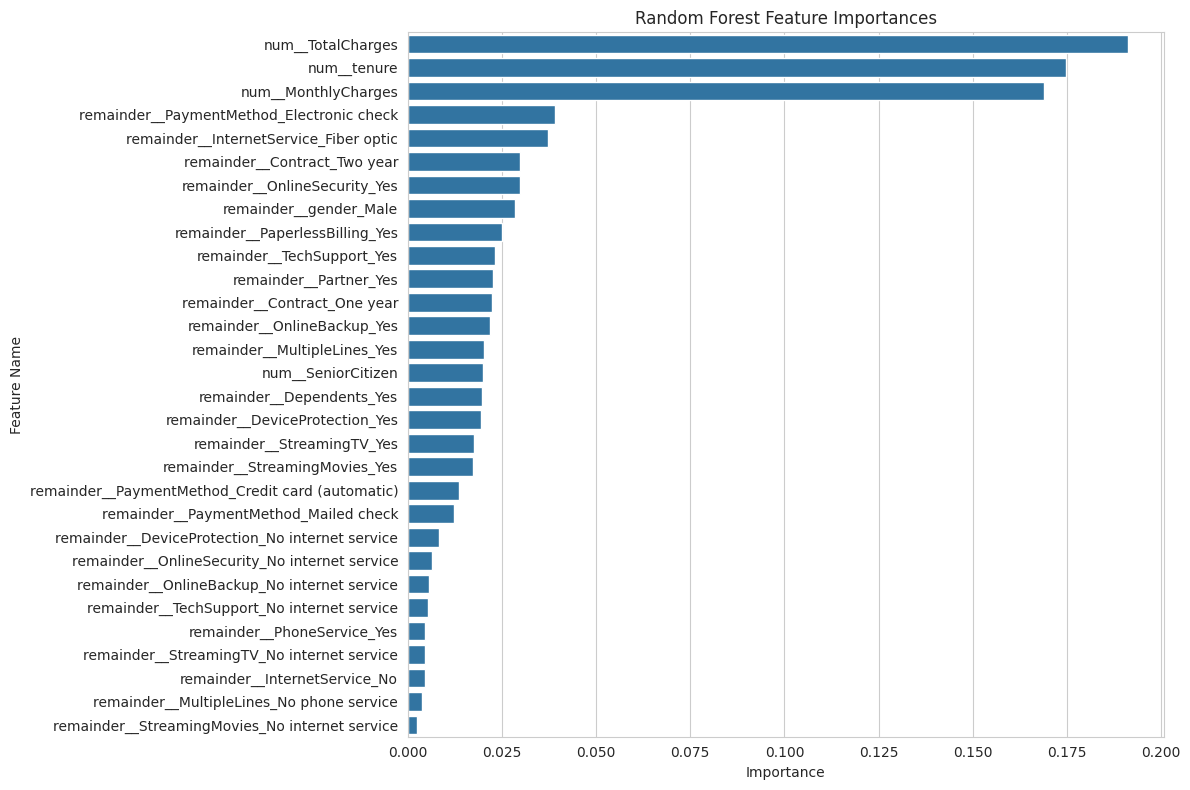

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Get the Random Forest classifier from the pipeline
rf_classifier = model_pipeline_rf.named_steps['classifier']

# Get feature importances
feature_importances = rf_classifier.feature_importances_

# Get feature names from the preprocessor step
# The ColumnTransformer has a 'get_feature_names_out' method
# However, it might prepend prefixes like 'num__' or 'passthrough__'.
# We need to correctly map them back to original feature names.

# Get names of features after preprocessing
preprocessor = model_pipeline_rf.named_steps['preprocessor']
feature_names_out = preprocessor.get_feature_names_out()

# Create a DataFrame for feature importances
feature_importance_df = pd.DataFrame({
    'Feature': feature_names_out,
    'Importance': feature_importances
})

# Sort by importance
feature_importance_df = feature_importance_df.sort_values(by='Importance', ascending=False)

# Plotting feature importances
plt.figure(figsize=(12, 8))
sns.barplot(x='Importance', y='Feature', data=feature_importance_df)
plt.title('Random Forest Feature Importances')
plt.xlabel('Importance')
plt.ylabel('Feature Name')
plt.tight_layout()
plt.show()

### Feature Importance for Logistic Regression Model

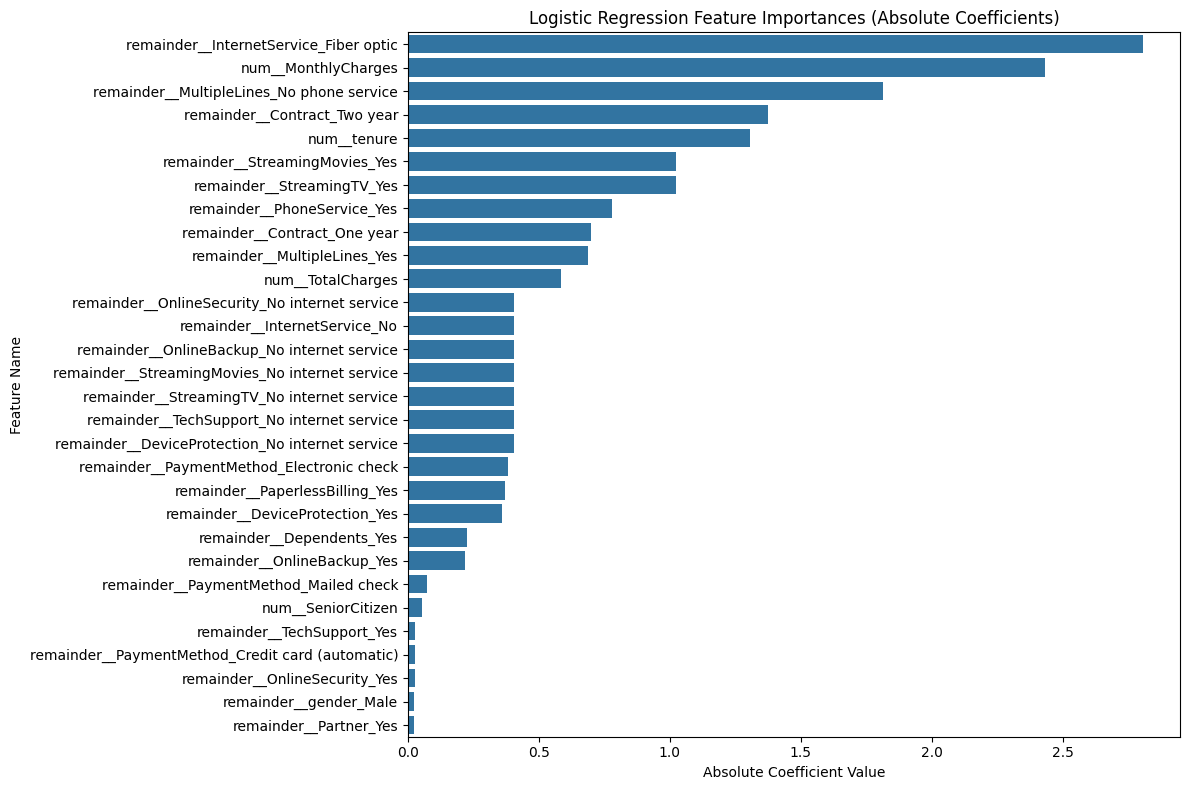

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Get the Logistic Regression classifier from the pipeline
lr_classifier = best_lr_model.named_steps['classifier']

# Get coefficients (feature importances) - absolute value for comparison
feature_importances_lr = abs(lr_classifier.coef_[0])

# Get feature names from the preprocessor step
preprocessor_lr = best_lr_model.named_steps['preprocessor']
feature_names_out_lr = preprocessor_lr.get_feature_names_out()

# Create a DataFrame for feature importances
feature_importance_df_lr = pd.DataFrame({
    'Feature': feature_names_out_lr,
    'Importance': feature_importances_lr
})

# Sort by importance
feature_importance_df_lr = feature_importance_df_lr.sort_values(by='Importance', ascending=False)

# Plotting feature importances
plt.figure(figsize=(12, 8))
sns.barplot(x='Importance', y='Feature', data=feature_importance_df_lr)
plt.title('Logistic Regression Feature Importances (Absolute Coefficients)')
plt.xlabel('Absolute Coefficient Value')
plt.ylabel('Feature Name')
plt.tight_layout()
plt.show()

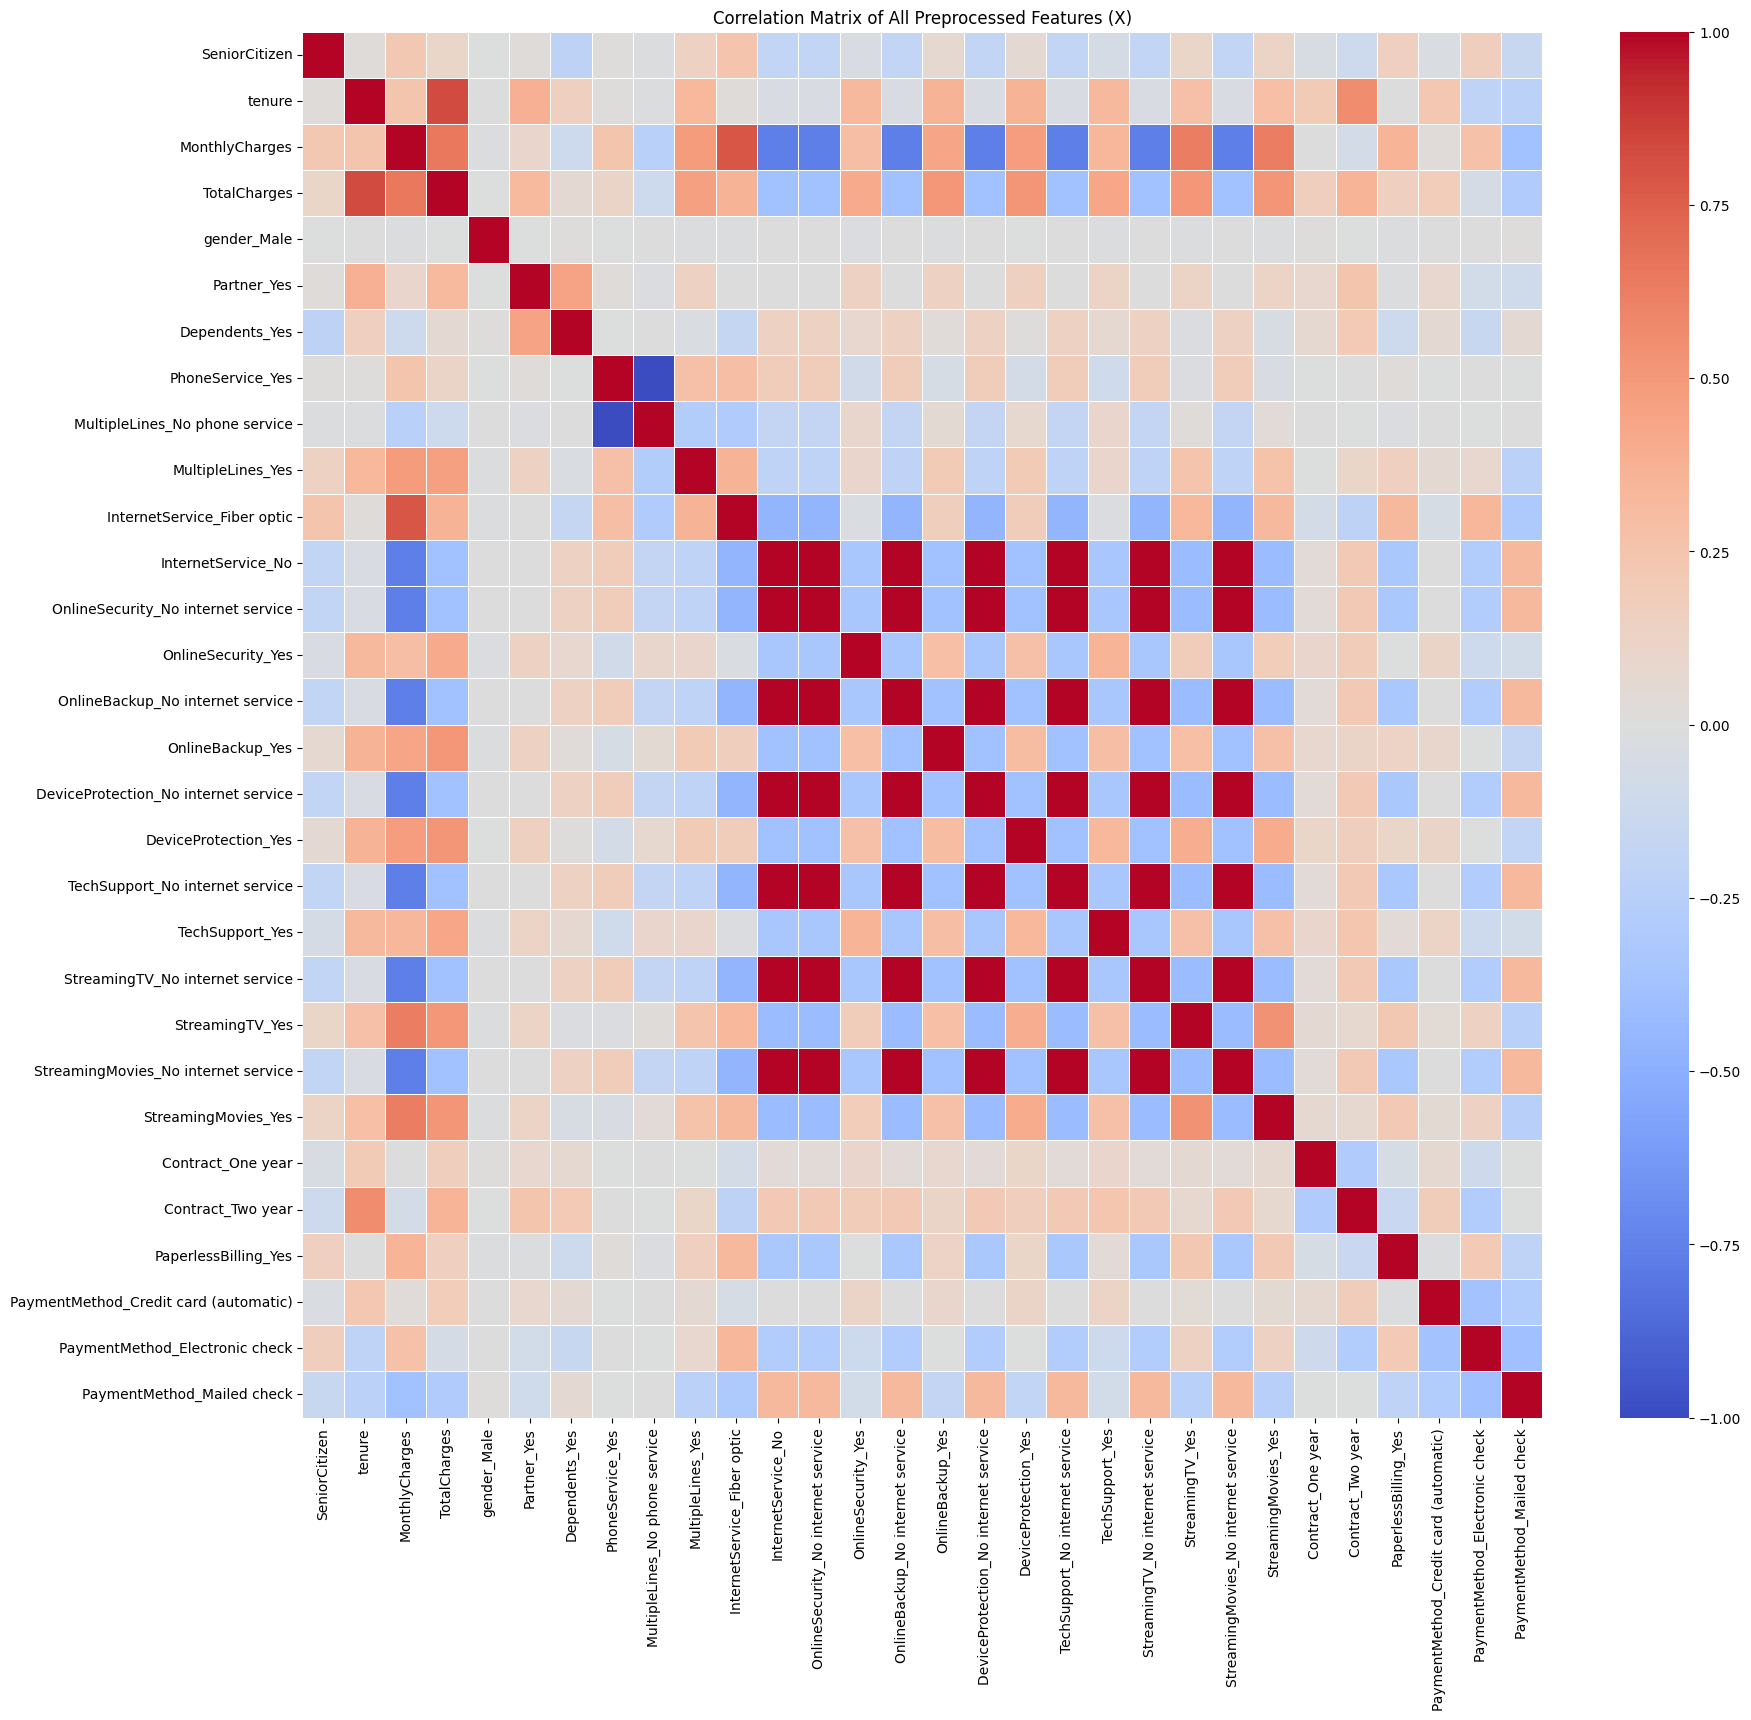

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Calculate the correlation matrix for the preprocessed features (X)
correlation_matrix_X = X.corr()

plt.figure(figsize=(20, 18)) # Adjust figure size for better readability
sns.heatmap(correlation_matrix_X, annot=False, cmap='coolwarm', fmt='.2f', linewidths=.5)
plt.title('Correlation Matrix of All Preprocessed Features (X)')
plt.show()


### Random Forest Feature Importance (Selected Features)

Based on your request, this plot highlights the importance of the most influential features identified by the Random Forest model: `TotalCharges`, `tenure`, `MonthlyCharges`, and features related to `PaymentMethod`.

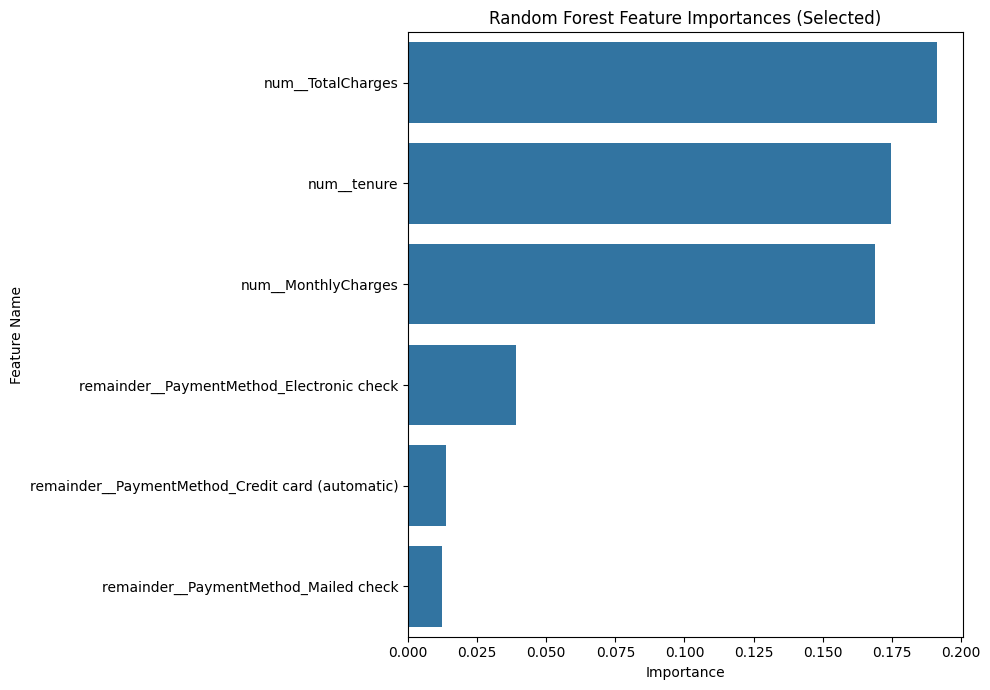

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Get the Random Forest classifier from the pipeline
rf_classifier = model_pipeline_rf.named_steps['classifier']

# Get feature importances
feature_importances = rf_classifier.feature_importances_

# Get feature names from the preprocessor step
preprocessor = model_pipeline_rf.named_steps['preprocessor']
feature_names_out = preprocessor.get_feature_names_out()

# Create a DataFrame for feature importances
feature_importance_df = pd.DataFrame({
    'Feature': feature_names_out,
    'Importance': feature_importances
})

# Sort by importance
feature_importance_df = feature_importance_df.sort_values(by='Importance', ascending=False)

# Define the features to highlight (case-insensitive and partial matching for PaymentMethod)
selected_feature_keywords = ['totalcharges', 'tenure', 'monthlycharges', 'paymentmethod']

# Filter the DataFrame for selected features
filtered_feature_importance_df = feature_importance_df[
    feature_importance_df['Feature'].str.lower().str.contains('totalcharges|tenure|monthlycharges|paymentmethod')
].copy()

# Sort the filtered DataFrame for plotting
filtered_feature_importance_df = filtered_feature_importance_df.sort_values(by='Importance', ascending=False)

# Plotting feature importances for selected features
plt.figure(figsize=(10, 7))
sns.barplot(x='Importance', y='Feature', data=filtered_feature_importance_df)
plt.title('Random Forest Feature Importances (Selected)')
plt.xlabel('Importance')
plt.ylabel('Feature Name')
plt.tight_layout()
plt.show()

In [ ]:
import pandas as pd
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn import set_config

# Re-load the dataset if not already in memory (assuming /content/Sahan Dataset Telco_Customer_Churn.csv is available)
# If df is already defined from a previous successful run, this will just re-create it.
df = pd.read_csv('/content/Sahan Dataset Telco_Customer_Churn.csv')

# Convert 'TotalCharges' to numeric and handle NaNs (from cell 1e4bad3e)
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
df['TotalCharges'] = df['TotalCharges'].fillna(0)

# Define target variable 'y' (from cell 256fc064)
y = df['Churn'].copy()

# Define features 'X' (all columns except 'customerID' and 'Churn')
X = df.drop(columns=['customerID', 'Churn']).copy()

# Encode the target variable 'y' (from cell 256fc064)
le = LabelEncoder()
y = le.fit_transform(y)

# One-Hot Encode features (from cell 29618206)
X = pd.get_dummies(X, drop_first=True)

# Split the data into training and testing sets (from cell 3dc3c277)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Identify numerical features for scaling (from cell 3dc3c277)
numerical_features = ['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges']

# Create a ColumnTransformer for preprocessing (from cell 3dc3c277)
# Added force_int_remainder_cols=False to suppress FutureWarning
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_features)
    ],
    remainder='passthrough',
    force_int_remainder_cols=False
)

# Create and train the Logistic Regression Pipeline (from cell 3dc3c277)
model_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(random_state=42, solver='liblinear'))
])
model_pipeline.fit(X_train, y_train)

# Create and train the Random Forest Pipeline (from cell 87e2b23e)
model_pipeline_rf = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier(random_state=42))
])
model_pipeline_rf.fit(X_train, y_train)

print("Models re-initialized successfully.")

Models re-initialized successfully.


In [ ]:
# Create a DataFrame of X_test with original index
X_test_df = X_test.copy()
X_test_df['y_test'] = y_test
X_test_df['y_pred_lr'] = y_pred

# Identify misclassified samples
misclassified_df = X_test_df[X_test_df['y_test'] != X_test_df['y_pred_lr']]

print(f"Total misclassified samples: {len(misclassified_df)}")

# Separate into False Positives and False Negatives
false_positives = misclassified_df[(misclassified_df['y_test'] == 0) & (misclassified_df['y_pred_lr'] == 1)]
false_negatives = misclassified_df[(misclassified_df['y_test'] == 1) & (misclassified_df['y_pred_lr'] == 0)]

print(f"Number of False Positives (Predicted Churn=Yes, Actual Churn=No): {len(false_positives)}")
print(f"Number of False Negatives (Predicted Churn=No, Actual Churn=Yes): {len(false_negatives)}")

print("\n--- Analysis of False Negatives (Actual Churners Missed by Model) ---\n")
print("Descriptive statistics for numerical features:")
display(false_negatives[numerical_features].describe())

print("\nValue counts for some categorical features:")
for col in X.columns:
    # Only display value counts for boolean columns or columns with less than 10 unique values
    if X[col].dtype == 'bool' or X[col].nunique() < 10:
        print(f"\n{col}:")
        print(false_negatives[col].value_counts())


print("\n--- Analysis of False Positives (Non-Churners Incorrectly Predicted as Churners) ---\n")
print("Descriptive statistics for numerical features:")
display(false_positives[numerical_features].describe())

print("\nValue counts for some categorical features:")
for col in X.columns:
    # Only display value counts for boolean columns or columns with less than 10 unique values
    if X[col].dtype == 'bool' or X[col].nunique() < 10:
        print(f"\n{col}:")
        print(false_positives[col].value_counts())


Total misclassified samples: 275
Number of False Positives (Predicted Churn=Yes, Actual Churn=No): 109
Number of False Negatives (Predicted Churn=No, Actual Churn=Yes): 166

--- Analysis of False Negatives (Actual Churners Missed by Model) ---

Descriptive statistics for numerical features:


,SeniorCitizen,tenure,MonthlyCharges,TotalCharges
count,166.000000,166.000000,166.000000,166.000000
mean,0.198795,24.506024,65.035542,2056.345482
std,0.400301,22.471463,29.166174,2266.624748
min,0.000000,1.000000,18.950000,19.300000
25%,0.000000,3.000000,45.512500,98.525000
50%,0.000000,17.500000,60.375000,1173.800000
75%,0.000000,44.250000,93.462500,3178.687500
max,1.000000,72.000000,115.650000,7968.850000



Value counts for some categorical features:

SeniorCitizen:
SeniorCitizen
0    133
1     33
Name: count, dtype: int64

gender_Male:
gender_Male
False    92
True     74
Name: count, dtype: int64

Partner_Yes:
Partner_Yes
False    93
True     73
Name: count, dtype: int64

Dependents_Yes:
Dependents_Yes
False    117
True      49
Name: count, dtype: int64

PhoneService_Yes:
PhoneService_Yes
True     150
False     16
Name: count, dtype: int64

MultipleLines_No phone service:
MultipleLines_No phone service
False    150
True      16
Name: count, dtype: int64

MultipleLines_Yes:
MultipleLines_Yes
False    109
True      57
Name: count, dtype: int64

InternetService_Fiber optic:
InternetService_Fiber optic
False    97
True     69
Name: count, dtype: int64

InternetService_No:
InternetService_No
False    141
True      25
Name: count, dtype: int64

OnlineSecurity_No internet service:
OnlineSecurity_No internet service
False    141
True      25
Name: count, dtype: int64

OnlineSecurity_Yes:
Online

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges
count,109.000000,109.000000,109.000000,109.000000
mean,0.266055,12.990826,80.700459,1140.947248
std,0.443934,11.323113,15.799834,1132.204887
min,0.000000,1.000000,24.900000,49.700000
25%,0.000000,4.000000,73.850000,302.600000
50%,0.000000,8.000000,80.150000,632.200000
75%,1.000000,21.000000,90.750000,1818.900000
max,1.000000,46.000000,111.400000,4863.850000



Value counts for some categorical features:

SeniorCitizen:
SeniorCitizen
0    80
1    29
Name: count, dtype: int64

gender_Male:
gender_Male
True     58
False    51
Name: count, dtype: int64

Partner_Yes:
Partner_Yes
False    82
True     27
Name: count, dtype: int64

Dependents_Yes:
Dependents_Yes
False    97
True     12
Name: count, dtype: int64

PhoneService_Yes:
PhoneService_Yes
True     104
False      5
Name: count, dtype: int64

MultipleLines_No phone service:
MultipleLines_No phone service
False    104
True       5
Name: count, dtype: int64

MultipleLines_Yes:
MultipleLines_Yes
True     57
False    52
Name: count, dtype: int64

InternetService_Fiber optic:
InternetService_Fiber optic
True     98
False    11
Name: count, dtype: int64

InternetService_No:
InternetService_No
False    109
Name: count, dtype: int64

OnlineSecurity_No internet service:
OnlineSecurity_No internet service
False    109
Name: count, dtype: int64

OnlineSecurity_Yes:
OnlineSecurity_Yes
False    103
True  

### Hyperparameter Tuning for Logistic Regression (C Parameter)

In [ ]:
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report

# Define the parameter grid for Logistic Regression
# The 'C' parameter controls the inverse of regularization strength
param_grid_lr = {
    'classifier__C': [0.001, 0.01, 0.1, 1, 10, 100]
}

# Create a GridSearchCV object
# We use the existing 'model_pipeline' which includes the preprocessor
grid_search_lr = GridSearchCV(
    model_pipeline,
    param_grid_lr,
    cv=5,
    scoring='f1', # Optimize for F1-score given churn imbalance
    n_jobs=-1, # Use all available cores
    verbose=1
)

# Fit GridSearchCV to the training data
grid_search_lr.fit(X_train, y_train)

print("Best parameters for Logistic Regression:", grid_search_lr.best_params_)
print("Best F1-Score for Logistic Regression:", grid_search_lr.best_score_)

# Get the best model
best_lr_model = grid_search_lr.best_estimator_

# Evaluate the best model on the test set
y_pred_best_lr = best_lr_model.predict(X_test)

accuracy_best_lr = accuracy_score(y_test, y_pred_best_lr)
precision_best_lr = precision_score(y_test, y_pred_best_lr)
recall_best_lr = recall_score(y_test, y_pred_best_lr)
f1_best_lr = f1_score(y_test, y_pred_best_lr)

print(f"\nBest Logistic Regression Model Accuracy on Test Set: {accuracy_best_lr:.4f}")
print(f"Best Logistic Regression Model Precision on Test Set: {precision_best_lr:.4f}")
print(f"Best Logistic Regression Model Recall on Test Set: {recall_best_lr:.4f}")
print(f"Best Logistic Regression Model F1-Score on Test Set: {f1_best_lr:.4f}")

print("\nClassification Report for Best Logistic Regression Model:")
print(classification_report(y_test, y_pred_best_lr))

Fitting 5 folds for each of 6 candidates, totalling 30 fits
Best parameters for Logistic Regression: {'classifier__C': 100}
Best F1-Score for Logistic Regression: 0.5998839580442928

Best Logistic Regression Model Accuracy on Test Set: 0.8020
Best Logistic Regression Model Precision on Test Set: 0.6498
Best Logistic Regression Model Recall on Test Set: 0.5508
Best Logistic Regression Model F1-Score on Test Set: 0.5962

Classification Report for Best Logistic Regression Model:
              precision    recall  f1-score   support

           0       0.85      0.89      0.87      1035
           1       0.65      0.55      0.60       374

    accuracy                           0.80      1409
   macro avg       0.75      0.72      0.73      1409
weighted avg       0.79      0.80      0.80      1409



### Hyperparameter Tuning for Random Forest (RandomizedSearchCV)

In [ ]:
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import randint

# Define the parameter distributions for Random Forest
param_dist_rf = {
    'classifier__n_estimators': randint(100, 500), # Number of trees in the forest
    'classifier__max_features': ['sqrt', 'log2'], # Number of features to consider at every split
    'classifier__max_depth': randint(10, 100), # Maximum number of levels in tree
    'classifier__min_samples_split': randint(2, 20), # Minimum number of samples required to split an internal node
    'classifier__min_samples_leaf': randint(1, 20), # Minimum number of samples required to be at a leaf node
    'classifier__bootstrap': [True, False] # Method for sampling training data
}

# Create a RandomizedSearchCV object
# We use the existing 'model_pipeline_rf' which includes the preprocessor
random_search_rf = RandomizedSearchCV(
    model_pipeline_rf,
    param_distributions=param_dist_rf,
    n_iter=50, # Number of parameter settings that are sampled. Trade-off between runtime and performance.
    cv=5,
    scoring='f1', # Optimize for F1-score given churn imbalance
    random_state=42,
    n_jobs=-1, # Use all available cores
    verbose=1
)

# Fit RandomizedSearchCV to the training data
random_search_rf.fit(X_train, y_train)

print("Best parameters for Random Forest:", random_search_rf.best_params_)
print("Best F1-Score for Random Forest:", random_search_rf.best_score_)

# Get the best model
best_rf_model = random_search_rf.best_estimator_

# Evaluate the best model on the test set
y_pred_best_rf = best_rf_model.predict(X_test)

accuracy_best_rf = accuracy_score(y_test, y_pred_best_rf)
precision_best_rf = precision_score(y_test, y_pred_best_rf)
recall_best_rf = recall_score(y_test, y_pred_best_rf)
f1_best_rf = f1_score(y_test, y_pred_best_rf)

print(f"\nBest Random Forest Model Accuracy on Test Set: {accuracy_best_rf:.4f}")
print(f"Best Random Forest Model Precision on Test Set: {precision_best_rf:.4f}")
print(f"Best Random Forest Model Recall on Test Set: {recall_best_rf:.4f}")
print(f"Best Random Forest Model F1-Score on Test Set: {f1_best_rf:.4f}")

print("\nClassification Report for Best Random Forest Model:")
print(classification_report(y_test, y_pred_best_rf))

Fitting 5 folds for each of 50 candidates, totalling 250 fits
Best parameters for Random Forest: {'classifier__bootstrap': True, 'classifier__max_depth': 10, 'classifier__max_features': 'sqrt', 'classifier__min_samples_leaf': 13, 'classifier__min_samples_split': 10, 'classifier__n_estimators': 358}
Best F1-Score for Random Forest: 0.5688484630668112

Best Random Forest Model Accuracy on Test Set: 0.8027
Best Random Forest Model Precision on Test Set: 0.6714
Best Random Forest Model Recall on Test Set: 0.5027
Best Random Forest Model F1-Score on Test Set: 0.5749

Classification Report for Best Random Forest Model:
              precision    recall  f1-score   support

           0       0.84      0.91      0.87      1035
           1       0.67      0.50      0.57       374

    accuracy                           0.80      1409
   macro avg       0.75      0.71      0.72      1409
weighted avg       0.79      0.80      0.79      1409



In [ ]:
import joblib

# Ensure 'best_rf_model' is defined by running the Random Forest hyperparameter tuning cell (cbabc3f5) first.
joblib.dump(best_rf_model, "churn_rf_pipeline.joblib")

NameError: name 'best_rf_model' is not defined

### Load and Verify the Saved Model

In [ ]:
import joblib
import pandas as pd

# Load the saved Random Forest model pipeline
loaded_rf_pipeline = joblib.load("churn_rf_pipeline.joblib")

# Verify the loaded model by making predictions on a small sample of X_test
# Make sure X_test is available (it should be if previous cells were run)
sample_X_test = X_test.head(5)
predicted_churn_sample = loaded_rf_pipeline.predict(sample_X_test)

print("Loaded model successfully!")
print("\nSample X_test (first 5 rows):")
display(sample_X_test)
print("\nPredicted Churn for sample X_test:")
print(predicted_churn_sample)

# Optionally, compare with actual y_test values for the sample
print("\nActual Churn for sample X_test:")
print(y_test[:5])

FileNotFoundError: [Errno 2] No such file or directory: 'churn_rf_pipeline.joblib'

In [ ]:
import os

file_path = "churn_rf_pipeline.joblib"
if os.path.exists(file_path):
    print(f"The file '{file_path}' exists. You can now confidently load it.")
else:
    print(f"The file '{file_path}' does not exist. Please ensure cells `cbabc3f5` and `63LkjoJRHrLO` were run successfully.")

The file 'churn_rf_pipeline.joblib' does not exist. Please ensure cells `cbabc3f5` and `63LkjoJRHrLO` were run successfully.


### Correctly Saving a Model with `joblib`

To save a model correctly, you first need to have an instantiated and trained model object. Then, you use `joblib.dump()` to save it to a file.

In [ ]:
import joblib
from sklearn.linear_model import LogisticRegression

# 1. Create a dummy model (replace with your actual trained model)
# For demonstration, let's create a simple Logistic Regression model
# and 'train' it with some dummy data if it's not already trained.
# In your case, this would be your `best_rf_model` or `best_lr_model`.

# Dummy data for demonstration
X_dummy = [[1, 2], [3, 4], [5, 6], [7, 8]]
y_dummy = [0, 1, 0, 1]

dummy_model = LogisticRegression(random_state=42)
dummy_model.fit(X_dummy, y_dummy)

# 2. Define the filename for your saved model
model_filename = 'my_dummy_model.joblib'

# 3. Save the model using joblib.dump()
joblib.dump(dummy_model, model_filename)

print(f"Model successfully saved to '{model_filename}'")

Model successfully saved to 'my_dummy_model.joblib'


### Verifying the Saved Model

After saving, you can load the model back and verify its functionality.

In [ ]:
import joblib
import os

model_filename = 'my_dummy_model.joblib'

# Check if the file exists before attempting to load
if os.path.exists(model_filename):
    # Load the model
    loaded_model = joblib.load(model_filename)
    print(f"Model '{model_filename}' successfully loaded!")

    # Verify by making a prediction with the loaded model
    sample_data = [[2, 3]]
    prediction = loaded_model.predict(sample_data)
    print(f"Prediction from loaded model for {sample_data}: {prediction}")
else:
    print(f"Error: Model file '{model_filename}' not found.")

Model 'my_dummy_model.joblib' successfully loaded!
Prediction from loaded model for [[2, 3]]: [0]


In [ ]:
from google.colab import files

files.download('my_dummy_model.joblib')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

MessageError: Error: credential propagation was unsuccessful

After running the cell above and following the authentication steps, your Google Drive will be mounted at `/content/drive`. Now, you can copy the `my_dummy_model.joblib` file to a folder in your Drive. For example, to copy it to a folder named `Colab Notebooks` in your Drive, use the following command:

In [ ]:
import shutil
import os

source_path = 'my_dummy_model.joblib'
destination_folder = '/content/drive/MyDrive/Colab Notebooks' # Or any other folder in your Drive

# Create the destination folder if it doesn't exist
os.makedirs(destination_folder, exist_ok=True)

# Copy the file
shutil.copy(source_path, destination_folder)

print(f"'{source_path}' copied to '{destination_folder}'")

'my_dummy_model.joblib' copied to '/content/drive/MyDrive/Colab Notebooks'


In [ ]:
import os
print("saved at:",os.getcwd())

saved at: /content


In [1]:
import joblib

joblib.dump(model, "churn_pipeline.joblib")

NameError: name 'model' is not defined